In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# Loading the dataset
house_Price_Data = pd.read_csv("HousePricePrediction.csv")

In [3]:
# Reading the data
house_Price_Data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


<Axes: xlabel='OverallCond', ylabel='SalePrice'>

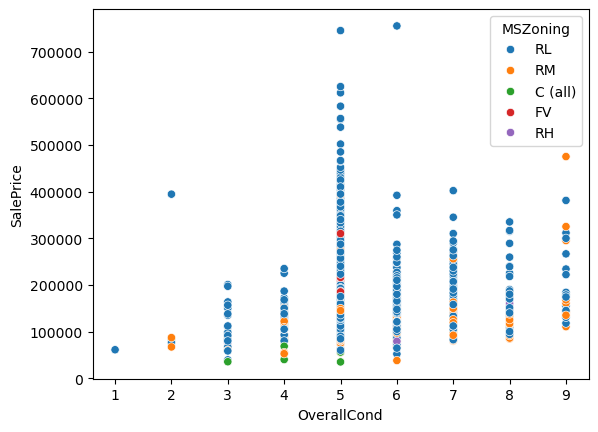

In [4]:
# Visualization
sns.scatterplot(x = house_Price_Data["OverallCond"], y = house_Price_Data["SalePrice"], hue = house_Price_Data["MSZoning"])

In [5]:
# Declaring Independent and Dependent variables
X = house_Price_Data.drop(columns = ["Id", "BldgType", "BsmtFinSF2", "SalePrice"])
y = house_Price_Data["SalePrice"]

#### Feature Engineering

# Encoding text with numbers, here used pands to categories into ihe group insted of giving 1 and 0,  best approach
X = pd.get_dummies(X, columns =  ["MSZoning", "LotConfig", "Exterior1st"])

#  Creating New House Age Feature: Only House Year doesn't tell  the model much about it's impact on the sale price instead the age tells the imapct.
X["HouseAge"] = 2026 -X["YearBuilt"]
X["YearSinceRemodal"] = 2026 - X["YearRemodAdd"]

# Dropping the prvious year columns
X = X.drop(columns = ["YearBuilt", "YearRemodAdd"])

In [6]:
# Hanldiling Values 
# Checking if Null present

X.isnull().sum()
X["TotalBsmtSF"] = X["TotalBsmtSF"].fillna(X["TotalBsmtSF"].median())
y = y.fillna(y.median())

In [7]:
#  Chaning the number (which represent only label) to str and hot encoding as welll.
X["MSSubClass"] = X["MSSubClass"].astype(str)
X = pd.get_dummies(X, columns = ["MSSubClass"])

In [8]:
bool_cols = X.select_dtypes(include = "bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [9]:
#  Filtering the rows with less than 400000 sales price
mask = y < 400_000
y = y[mask]
X = X[mask]

In [10]:
# Feature Scaling: Needed in Linear Regreesion Algorithm to manage the scales of differnt columns, to bring them to similar scales.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X.head()

,LotArea,OverallCond,TotalBsmtSF,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LotConfig_Corner,LotConfig_CulDSac,...,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90
0,8450,5,856.0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,9600,8,1262.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,11250,5,920.0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,9550,5,756.0,0,0,0,1,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,14260,5,1145.0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [12]:
#  Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [13]:
X_train.head()

,LotArea,OverallCond,TotalBsmtSF,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LotConfig_Corner,LotConfig_CulDSac,...,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90
2369,2280,5,744.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2418,7150,4,1190.0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
830,11900,5,1392.0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1383,25339,7,816.0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1606,12760,5,1958.0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [14]:
# Training the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Evaluating the model
from sklearn.metrics import mean_absolute_error,  r2_score

# Make Prediction on test data
y_pred =  model.predict(X_test)

# Check Accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: $28,628
R² Score: 0.2769


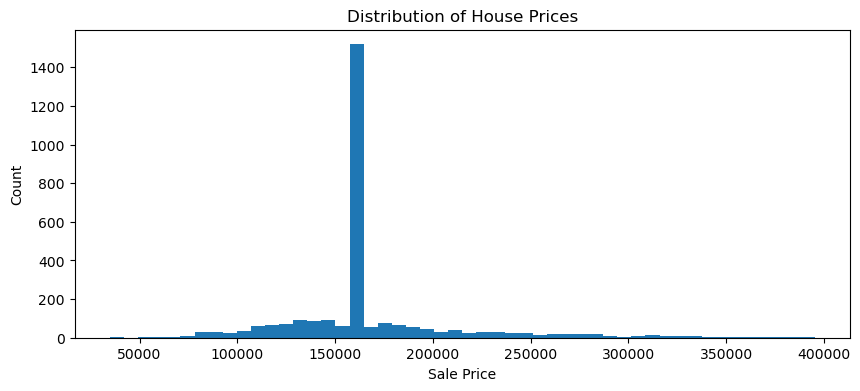

Max Price: $395,192
Min Price: $34,900
Mean Price: $168,881
Median Price: $163,000


In [16]:
# Checking for outliers

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(y,bins=50)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()


print(f"Max Price: ${y.max():,.0f}")
print(f"Min Price: ${y.min():,.0f}")
print(f"Mean Price: ${y.mean():,.0f}")
print(f"Median Price: ${y.median():,.0f}")